In [21]:
import time
import numpy as np
import matplotlib.pyplot as plt\

def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]
    
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    return C

Matrix Size     | Naive (s)    | NumPy (s)   
--------------------------------------------------------
3 x 3          | 0.000021     | 0.000041    
6 x 6          | 0.000057     | 0.000015    
12 x 12         | 0.000390     | 0.000024    
24 x 24         | 0.002561     | 0.000025    
48 x 48         | 0.019834     | 0.000073    
96 x 96         | 0.155774     | 0.000264    
192 x 192        | 1.242608     | 0.000725    
384 x 384        | 12.084440    | 0.003495    


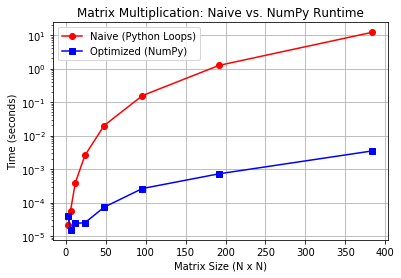

In [22]:
#Data
size = []
naive_time = []
np_time = []
n = 3

print(f"{'Matrix Size':<15} | {'Naive (s)':<12} | {'NumPy (s)':<12}")
print("--------------------------------------------------------")

for i in range(8):
    #Generate matrices
    A_list = np.random.rand(n, n).tolist()
    B_list = np.random.rand(n, n).tolist()
    A_np = np.array(A_list)
    B_np = np.array(B_list)
    
    #Naive Multiplication
    start = time.perf_counter()
    naive_matrix_multiplication(A_list, B_list)
    end = time.perf_counter()
    t_naive = end - start
    
    #np Multiplication
    start = time.perf_counter()
    np.dot(A_np, B_np)
    end = time.perf_counter()
    t_np = end - start
    
    #results
    size.append(n)
    naive_time.append(t_naive)
    np_time.append(t_np)
    
    print(f"{n} x {n:<10} | {t_naive:<12.6f} | {t_np:<12.6f}")
    n = 2*n
    
#Graphing
plt.plot(size, naive_time, 'o-', label='Naive (Python Loops)', color='r')
plt.plot(size, np_time, 's-', label='Optimized (NumPy)', color='b')

plt.title('Matrix Multiplication: Naive vs. NumPy Runtime')
plt.xlabel('Matrix Size (N x N)')
plt.ylabel('Time (seconds)')
plt.yscale('log')
#Used log scale to better see trend in data
plt.grid(True)
plt.legend()
plt.show()

The Naive time initially outperforms the numpy time, however, at larger and larger marices, the optimized numpy matrix multiplication outperforms the naive one.

Had to look up online the time function again because I forgot it.